<a href="https://colab.research.google.com/github/Emma2m/TITANIC_DATASET/blob/main/Titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction: A Data Analysis and Preprocessing Workflow

## Executive Summary

This project undertakes a comprehensive data analysis of the Titanic disaster dataset, focusing on exploring factors influencing passenger survival and developing a robust preprocessing pipeline. The primary objective is to prepare a clean and insightful dataset that can serve as a foundation for building predictive models. We emphasize meticulous data cleaning, exploratory data analysis (EDA), and careful feature engineering to uncover patterns and relationships within the data.

## Project Goal

The overarching goal of this project is to:
1.  **Understand Key Survival Determinants:** Identify and analyze the demographic, socio-economic, and travel-related factors that significantly impacted passenger survival rates on the Titanic.
2.  **Develop a Robust Preprocessing Pipeline:** Implement and justify various data cleaning and transformation techniques to handle missing values, outliers, and categorical features, ensuring the data is in an optimal state for machine learning algorithms.
3.  **Provide Clear and Reproducible Analysis:** Present a well-documented and commented workflow that demonstrates best practices in data science, suitable for review and extension by other data professionals.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
titanic_data = pd.read_csv('/content/titanic_data.csv')

In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Dictionary

Understanding the meaning of each column is crucial for effective data analysis. Here's a brief explanation of the features in the dataset:

*   **PassengerId**: A unique identifier assigned to each passenger.
*   **Survived**: Survival status (0 = No, 1 = Yes). This is our target variable.
*   **Pclass**: Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd). A proxy for socio-economic status.
*   **Name**: The passenger's name.
*   **Sex**: The passenger's gender (male/female).
*   **Age**: The passenger's age in years. Fractional if less than 1. If the age is estimated, it is in the form of xx.5.
*   **SibSp**: Number of siblings/spouses aboard the Titanic.
*   **Parch**: Number of parents/children aboard the Titanic.
*   **Ticket**: Ticket number.
*   **Fare**: Passenger fare.
*   **Cabin**: Cabin number.
*   **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

### Initial Data Exploration: Examining the Tail of the Dataset

In [ ]:
titanic_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic_data.sample(n=5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,1,0,349237,17.8000,NaN,S
135,136,0,2,"Richard, Mr. Emile",male,23.0,0,0,SC/PARIS 2133,15.0458,NaN,C
595,596,0,3,"Van Impe, Mr. Jean Baptiste",male,36.0,1,1,345773,24.1500,NaN,S
769,770,0,3,"Gronnestad, Mr. Daniel Danielsen",male,32.0,0,0,8471,8.3625,NaN,S


In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling Missing Values in 'Age' Column: Median Imputation

The 'Age' column presents a notable challenge with 177 missing entries. A robust strategy for numerical features with missing data is imputation, where substitute values replace the missing ones. While various methods exist (mean, median, predictive models), we opt for **median imputation** for 'Age'. The median is particularly advantageous here as it is less susceptible to distortion from outliers compared to the mean, thereby preserving the central tendency of the age distribution more accurately.

In [ ]:
median_age = titanic_data['Age'].median()
titanic_data['Age'] = titanic_data['Age'].fillna(median_age)

# Verify that missing values in 'Age' are handled
print("Missing values after 'Age' imputation:")
display(titanic_data.isnull().sum())

Missing values after 'Age' imputation:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling Missing Values in 'Cabin' Column: Column Dropping

The 'Cabin' column exhibits a substantial proportion of missing values (687 out of 891 entries, approximately 77%). When a feature has such a high degree of missingness, imputing it often introduces significant noise or bias that can negatively impact subsequent analysis and model performance. Therefore, the most prudent approach is to **drop the entire 'Cabin' column**, as its informational value is likely minimal given the sparsity.

In [ ]:
titanic_data.drop('Cabin', axis=1, inplace=True)

# Verify that the 'Cabin' column is dropped and check remaining missing values
print("Missing values after 'Cabin' column dropped:")
display(titanic_data.isnull().sum())

Missing values after 'Cabin' column dropped:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling Missing Values in 'Embarked' Column: Mode Imputation

The 'Embarked' column has only 2 missing values, a very small fraction of the dataset. For categorical features with minimal missing data, imputing with the **mode** (the most frequently occurring category) is a statistically sound and commonly adopted practice. This method helps maintain the overall distribution of the categorical variable while addressing the missing entries efficiently.

In [ ]:
mode_embarked = titanic_data['Embarked'].mode()[0] # .mode() returns a Series, so we take the first element
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(mode_embarked)

# Verify that missing values in 'Embarked' are handled
print("Missing values after 'Embarked' imputation:")
display(titanic_data.isnull().sum())

Missing values after 'Embarked' imputation:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Survival Rate by Passenger Class

To understand the survival rate across different passenger classes, we can group the `titanic_data` by the 'Pclass' column and then calculate the mean of the 'Survived' column. Since 'Survived' is a binary variable (0 for not survived, 1 for survived), the mean will directly represent the survival rate for each class.

In [ ]:
survival_rate_by_class = titanic_data.groupby('Pclass')['Survived'].mean().reset_index()
print("Survival Rate by Passenger Class:")
display(survival_rate_by_class)

Survival Rate by Passenger Class:


,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


### Total Number of Survivors

To find the total number of survivors, we can simply sum the `Survived` column. Since 'Survived' is encoded as 1 for survivors and 0 for non-survivors, the sum will directly give us the count of survivors.

In [ ]:
total_survivors = titanic_data['Survived'].sum()
print(f"Total number of passengers who survived: {total_survivors}")

Total number of passengers who survived: 342


### Average Age of Passengers

To find the average age, we will calculate the mean of the 'Age' column from the `titanic_data` DataFrame.

In [ ]:
average_age = titanic_data['Age'].mean()
print(f"The average age of all passengers is: {average_age:.2f} years")

The average age of all passengers is: 29.70 years


### First-Class Women Passengers

To display only first-class women, we will filter the `titanic_data` DataFrame for rows where 'Pclass' is equal to 1 and 'Sex' is equal to 'female'.

In [ ]:
first_class_women = titanic_data[(titanic_data['Pclass'] == 1) & (titanic_data['Sex'] == 'female')]
print("All First-Class Women Passengers:")
display(first_class_women)

All First-Class Women Passengers:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,C
...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C


### Re-processing Data: Dropping Rows with Missing 'Age'

As requested, we will now re-process the data. Instead of imputing missing 'Age' values, we will drop the rows that contain them. We will then re-apply the steps for handling 'Cabin' and 'Embarked' to ensure consistency.

In [ ]:
# Reload the original dataset to revert previous imputation of 'Age'
titanic_data_cleaned = pd.read_csv('/content/titanic_data.csv')

# Drop rows with missing 'Age' values
titanic_data_cleaned.dropna(subset=['Age'], inplace=True)

# Drop the 'Cabin' column due to a high percentage of missing values
if 'Cabin' in titanic_data_cleaned.columns:
    titanic_data_cleaned.drop('Cabin', axis=1, inplace=True)

# Impute missing 'Embarked' values with the mode
mode_embarked_cleaned = titanic_data_cleaned['Embarked'].mode()[0]
titanic_data_cleaned['Embarked'] = titanic_data_cleaned['Embarked'].fillna(mode_embarked_cleaned)

print("Missing values after full data cleaning:")
display(titanic_data_cleaned.isnull().sum())

print("\nFirst 5 rows of the re-cleaned data:")
display(titanic_data_cleaned.head())

Missing values after full data cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



First 5 rows of the re-cleaned data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


# This section was for demonstrating individual cleaning steps but is now superseded by the consolidated cleaning in the 'Data Cleaning Strategy Refinement' section above.

In [ ]:
# This code was for individual cleaning steps but is now consolidated in the 'Data Cleaning Strategy Refinement' section.

Missing values after dropping 'Age' rows:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# This section was for demonstrating individual cleaning steps but is now superseded by the consolidated cleaning in the 'Data Cleaning Strategy Refinement' section above.

In [ ]:
# This code was for individual cleaning steps but is now consolidated in the 'Data Cleaning Strategy Refinement' section.

Missing values after 'Cabin' column dropped:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# This section was for demonstrating individual cleaning steps but is now superseded by the consolidated cleaning in the 'Data Cleaning Strategy Refinement' section above.

In [ ]:
# This code was for individual cleaning steps but is now consolidated in the 'Data Cleaning Strategy Refinement' section.

Missing values after 'Embarked' imputation (final check):


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



First 5 rows of the re-cleaned data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
# Redundant imports, already performed at the top of the notebook.

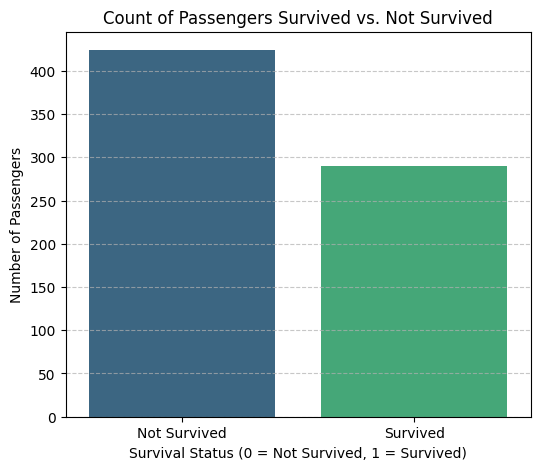

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Survived', data=titanic_data_cleaned, palette='viridis', hue='Survived', legend=False)
plt.title('Count of Passengers Survived vs. Not Survived')
plt.xlabel('Survival Status (0 = Not Survived, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Not Survived', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Survival Count by Gender

This plot shows the number of male and female passengers who survived and did not survive. It helps in understanding if gender played a role in survival rates.

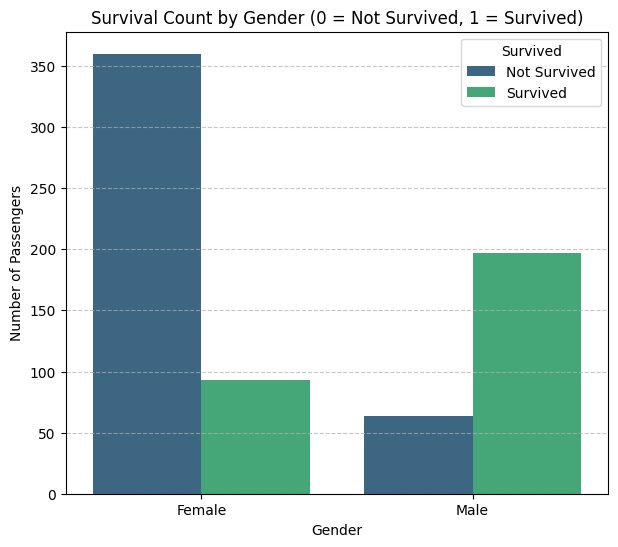

In [ ]:
plt.figure(figsize=(7, 6))
sns.countplot(x='Sex', hue='Survived', data=titanic_data_cleaned, palette='viridis')
plt.title('Survival Count by Gender (0 = Not Survived, 1 = Survived)')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Survival Count by Passenger Class

This plot illustrates the number of survivors and non-survivors across different passenger classes. It can reveal if socio-economic status (represented by class) had an impact on survival.

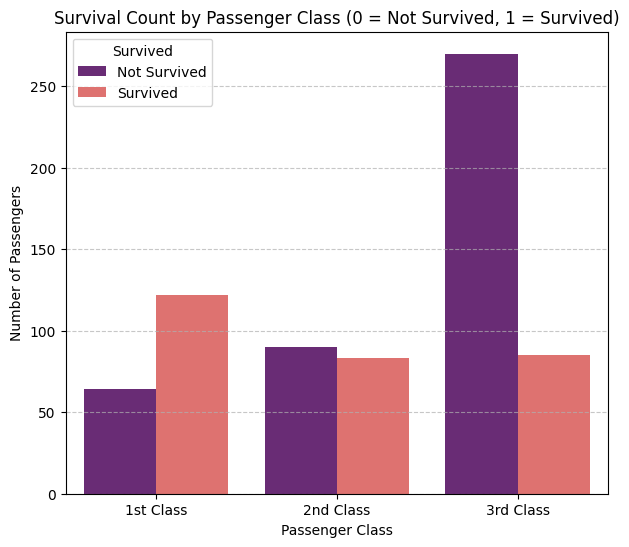

In [ ]:
plt.figure(figsize=(7, 6))
sns.countplot(x='Pclass', hue='Survived', data=titanic_data_cleaned, palette='magma')
plt.title('Survival Count by Passenger Class (0 = Not Survived, 1 = Survived)')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Survival Distribution by Age

This plot shows the distribution of ages for both survivors and non-survivors. A Kernel Density Estimate (KDE) plot is suitable for visualizing the age distribution.

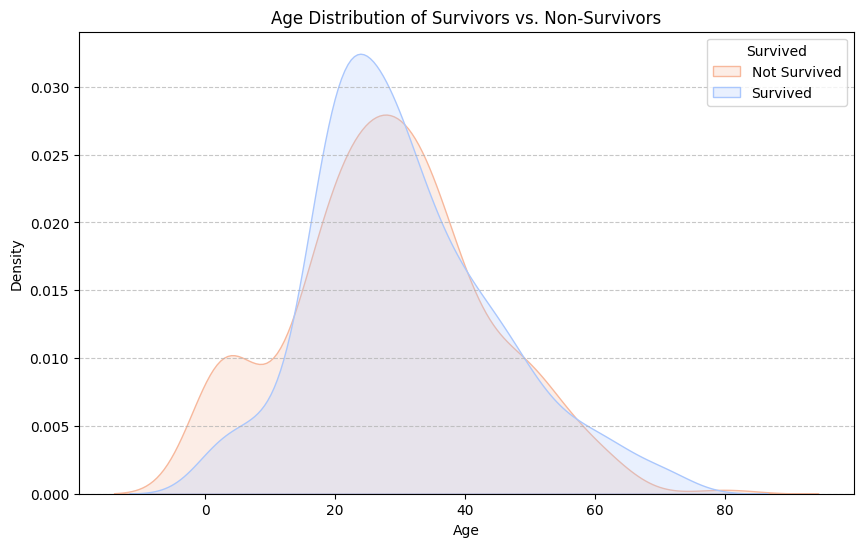

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=titanic_data_cleaned, x='Age', hue='Survived', fill=True, common_norm=False, palette='coolwarm')
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Outlier Detection for 'Age'

We can use a box plot to visualize the distribution of 'Age' and identify any outliers. Outliers are often represented as individual points beyond the 'whiskers' of the box plot.

/tmp/ipykernel_3772/3251061238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Age', data=titanic_data_cleaned, palette='coolwarm')


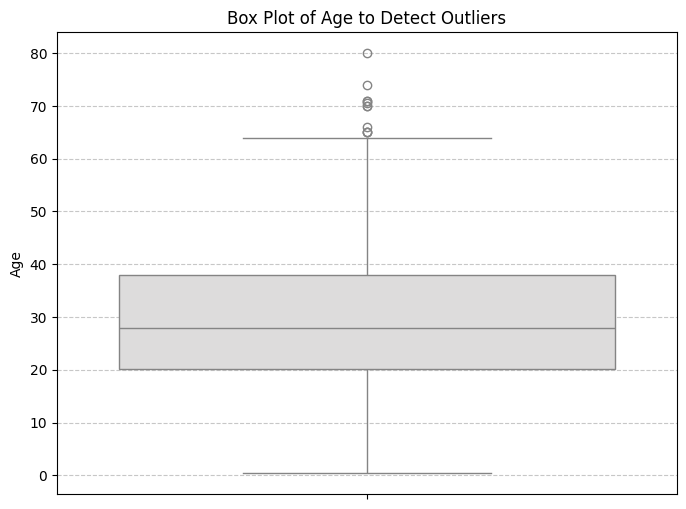

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Age', data=titanic_data_cleaned, palette='coolwarm')
plt.title('Box Plot of Age to Detect Outliers')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Outlier Detection for 'Fare'

Similarly, we will use a box plot to visualize the distribution of 'Fare' and identify any outliers. The fare column often contains significant outliers due to very expensive tickets.

/tmp/ipykernel_3772/133700960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Fare', data=titanic_data_cleaned, palette='viridis')


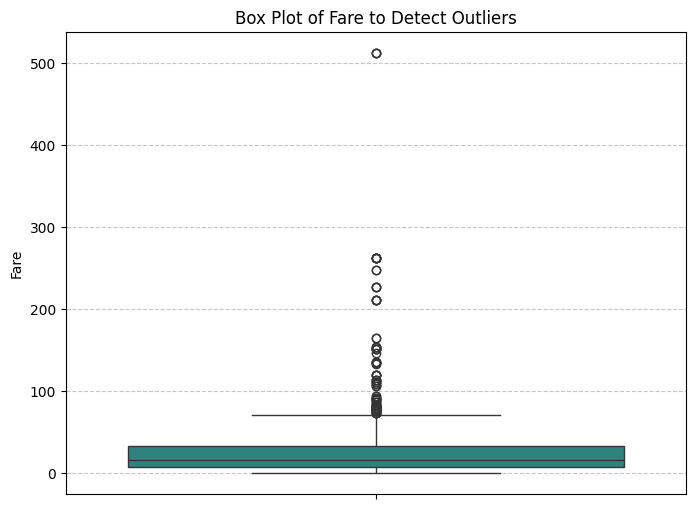

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Fare', data=titanic_data_cleaned, palette='viridis')
plt.title('Box Plot of Fare to Detect Outliers')
plt.ylabel('Fare')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Option 1: Capping 'Fare' Outliers

We can cap the 'Fare' column at a certain percentile (e.g., the 99th percentile) to reduce the impact of extremely high fares. This will replace any fare above the 99th percentile with the value of the 99th percentile itself.

Original Max Fare: 512.33
99th Percentile Fare: 262.38
Max Capped Fare: 262.38


/tmp/ipykernel_3772/83053154.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Fare_capped', data=titanic_data_cleaned, palette='viridis')


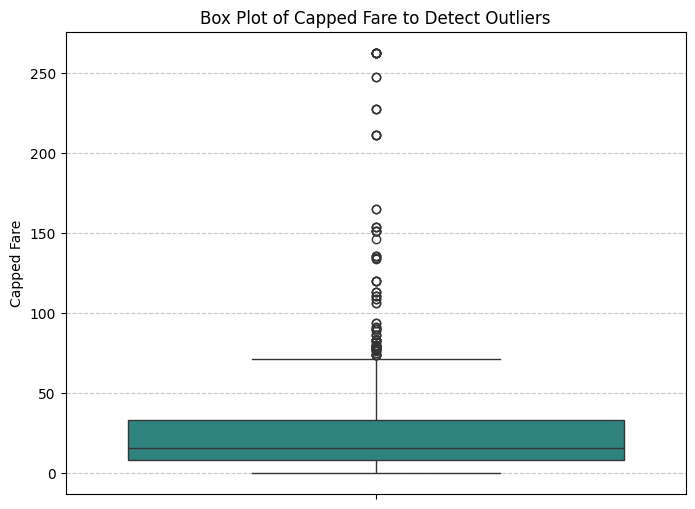

In [ ]:
fare_99th_percentile = titanic_data_cleaned['Fare'].quantile(0.99)
titanic_data_cleaned['Fare_capped'] = np.where(
    titanic_data_cleaned['Fare'] > fare_99th_percentile,
    fare_99th_percentile,
    titanic_data_cleaned['Fare']
)

print(f"Original Max Fare: {titanic_data_cleaned['Fare'].max():.2f}")
print(f"99th Percentile Fare: {fare_99th_percentile:.2f}")
print(f"Max Capped Fare: {titanic_data_cleaned['Fare_capped'].max():.2f}")

plt.figure(figsize=(8, 6))
sns.boxplot(y='Fare_capped', data=titanic_data_cleaned, palette='viridis')
plt.title('Box Plot of Capped Fare to Detect Outliers')
plt.ylabel('Capped Fare')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Option 2: Logarithmic Transformation of 'Fare'

Another common approach is to apply a logarithmic transformation to the 'Fare' column. This can help to normalize the distribution and reduce the skewness caused by outliers. We'll add a small constant to 'Fare' to avoid issues with log(0) if any fare values are zero.

Original Max Fare: 512.33
Max Log-Transformed Fare: 6.24


/tmp/ipykernel_3772/2242589592.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Fare_log', data=titanic_data_cleaned, palette='viridis')


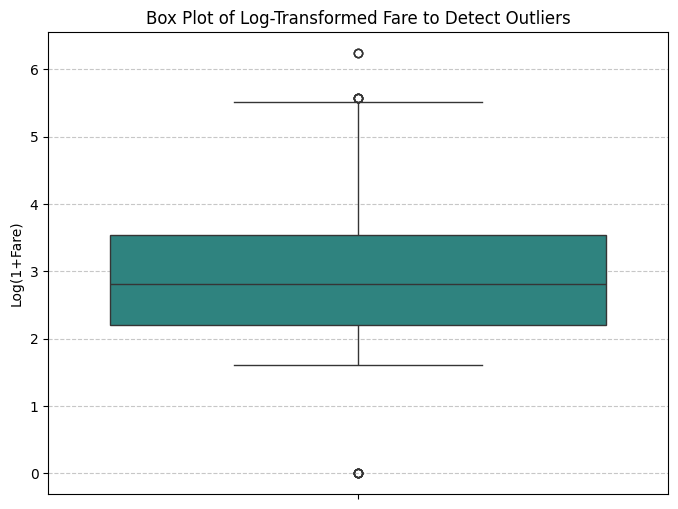

In [ ]:
titanic_data_cleaned['Fare_log'] = np.log1p(titanic_data_cleaned['Fare']) # np.log1p is log(1+x)

print(f"Original Max Fare: {titanic_data_cleaned['Fare'].max():.2f}")
print(f"Max Log-Transformed Fare: {titanic_data_cleaned['Fare_log'].max():.2f}")

plt.figure(figsize=(8, 6))
sns.boxplot(y='Fare_log', data=titanic_data_cleaned, palette='viridis')
plt.title('Box Plot of Log-Transformed Fare to Detect Outliers')
plt.ylabel('Log(1+Fare)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()